<a href="https://colab.research.google.com/github/Andreas-Lukito/Stock_Sentiment_Analysis/blob/dev%2Fandreas/notebooks/06_FinBERT_categorical_new_data_oversampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FinBERT for Predicting News Sentiment

## Install Libraries

In [33]:
! pip install contractions emoji gensim optuna torch matplotlib
! pip install wandb

## Iport Libraries

In [34]:
# Common Python Libraries
import numpy as np
import pandas as pd
import os
import sys
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import random
from datasets import Dataset

# Deep Learning Libraries
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer, EarlyStoppingCallback
from torch.optim import Adam, AdamW
from accelerate import Accelerator

# Data Preprocessing
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

## Download nltk dependencies
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')

# Model metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, RocCurveDisplay, f1_score, precision_score, recall_score, accuracy_score
from itertools import cycle
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Model Tracking
import wandb

# Google Colab Setup
from google.colab import drive
drive.mount('/content/drive')
project_path = "/content/drive/MyDrive/stock_news_sentiment_analysis"

# project_path = "../"

# Project Seed for Reproducability
SEED = random.randint(0, 2**32 - 1)  # Random integer between 0 and 2^32-1
print(f"seed: {SEED}")

model_name = "ProsusAI/finbert"

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
seed: 3735045561


## Choose Device

In [35]:
# Detect available device
if torch.cuda.is_available():
    # check if ROCm backend is active
    if torch.version.hip is not None:
        backend = "ROCm"
    else:
        backend = "CUDA"

    device = torch.device("cuda")
    print(f"PyTorch is using GPU: {torch.cuda.get_device_name(0)}")
    print(f"Backend: {backend}")
else:
    device = torch.device("cpu")
    print("PyTorch is not using GPU — running on CPU")

PyTorch is using GPU: NVIDIA A100-SXM4-80GB
Backend: CUDA


## Import Data

In [36]:
before_date = "2025-11"

# Data path
categorized_data_path = os.path.join(project_path,f"news_cache/catgorized_data/categorized_news_data_rescraped_cleaned.csv")

# Import Data
news_data = pd.read_csv(filepath_or_buffer=categorized_data_path, sep=',')

In [37]:
news_data.head()

,index,uuid,title,description,keywords,snippet,url,image_url,language,published_at,source,relevance_score,entities,similar,sentiment,text,clean_text,categorical_sentiment_3_class,length
0,0,487e6a88-d3c2-4ae1-8dc2-26af6b31d688,2025: The Year Of Alphabet (GOOG),No stock has seen a bigger jump recently than ...,NaN,vzphotos/iStock Editorial via Getty Images\n\n...,https://seekingalpha.com/article/4848680-2025-...,https://static.seekingalpha.com/cdn/s3/uploads...,en,2025-11-30T05:30:00.000000Z,seekingalpha.com,NaN,"[{'symbol': 'GOOGL', 'name': 'Alphabet Inc.', ...",[],0.0000,2025: The Year Of Alphabet (GOOG) No stock has...,2025 the year of alphabet goog no stock has se...,neutral,42
1,1,92b5c2bd-d324-4ae8-b115-2cfd95a8fa98,Why I'm Doubling Down On My Adobe Position (NA...,"Adobe's revenue is highly predictable, driven ...",NaN,To say that Adobe ( ADBE ) stock has not had a...,https://seekingalpha.com/article/4848762-why-i...,https://static.seekingalpha.com/cdn/s3/uploads...,en,2025-11-30T05:25:01.000000Z,seekingalpha.com,NaN,"[{'symbol': 'ADBE', 'name': 'Adobe Inc.', 'exc...",[],0.0000,Why I'm Doubling Down On My Adobe Position (NA...,why i am doubling down on my adobe position na...,neutral,259
2,2,9084e5f1-75f5-4f15-aa3d-0676073b4aaf,Global week ahead: The start of a Santa Rally ...,NaN,"STOXX 600, business news",And just like that... December is upon us. It'...,https://www.cnbc.com/2025/11/30/global-week-ah...,https://image.cnbcfm.com/api/v1/image/10823257...,en,2025-11-30T05:10:58.000000Z,cnbc.com,NaN,"[{'symbol': 'M', 'name': ""Macy's, Inc."", 'exch...",[],0.6908,Global week ahead: The start of a Santa Rally ...,global week ahead the start of a santa rally o...,positive,493
3,3,487e6a88-d3c2-4ae1-8dc2-26af6b31d688,2025: The Year Of Alphabet (GOOG),No stock has seen a bigger jump recently than ...,NaN,vzphotos/iStock Editorial via Getty Images\n\n...,https://seekingalpha.com/article/4848680-2025-...,https://static.seekingalpha.com/cdn/s3/uploads...,en,2025-11-30T05:30:00.000000Z,seekingalpha.com,NaN,"[{'symbol': 'GOOGL', 'name': 'Alphabet Inc.', ...",[],0.0000,2025: The Year Of Alphabet (GOOG) No stock has...,2025 the year of alphabet goog no stock has se...,neutral,42
4,4,92b5c2bd-d324-4ae8-b115-2cfd95a8fa98,Why I'm Doubling Down On My Adobe Position (NA...,"Adobe's revenue is highly predictable, driven ...",NaN,To say that Adobe ( ADBE ) stock has not had a...,https://seekingalpha.com/article/4848762-why-i...,https://static.seekingalpha.com/cdn/s3/uploads...,en,2025-11-30T05:25:01.000000Z,seekingalpha.com,NaN,"[{'symbol': 'ADBE', 'name': 'Adobe Inc.', 'exc...",[],0.0000,Why I'm Doubling Down On My Adobe Position (NA...,why i am doubling down on my adobe position na...,neutral,259


In [38]:
news_data.isna().sum()

,0
index,0
uuid,0
title,0
description,3148
keywords,35210
snippet,216
url,0
image_url,299
language,0
published_at,0


In [39]:
news_data = news_data.dropna(subset=["sentiment"])

In [40]:
news_data.isna().sum()

,0
index,0
uuid,0
title,0
description,3148
keywords,35207
snippet,216
url,0
image_url,299
language,0
published_at,0


In [41]:
value_maps = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

news_data["categorical_sentiment_3_class_value_maps"] = news_data["categorical_sentiment_3_class"].map(value_maps)

## Apply Random Oversampling

In [42]:
df = pd.DataFrame({
    "text": news_data["text"],
    "label": news_data["categorical_sentiment_3_class_value_maps"]
})

rus = RandomOverSampler(random_state=SEED)
X_resampled, y_resampled = rus.fit_resample(df[["text"]], df["label"])

ros_dataframe = pd.DataFrame({
    "text": X_resampled["text"],
    "label": y_resampled
})

## Split the data to Train, Test, and Validation

In [43]:
test_size = 0.10
val_size = 0.50

# Splitting the data into train and temp (which will be further split into validation and test)
train_df, test_df = train_test_split(ros_dataframe, test_size=test_size, random_state=SEED)

# Splitting train into validation and test sets
val_df, test_df = train_test_split(test_df, test_size=val_size, random_state=SEED)

In [44]:
train_df.shape, test_df.shape, val_df.shape

((85004, 2), (4723, 2), (4722, 2))

## Data Preprocessing

### Convert Dataframe to Dataset for the Model Trainer

In [45]:
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

### Tokenizer for the text

In [46]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples, tokenizer=tokenizer):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding=True,
        max_length=128   # keep this
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [47]:
train_ds = train_ds.map(tokenize_function, batched=True)
val_ds = val_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)

Map:   0%|          | 0/85004 [00:00<?, ? examples/s]

Map:   0%|          | 0/4722 [00:00<?, ? examples/s]

Map:   0%|          | 0/4723 [00:00<?, ? examples/s]

In [48]:
# remove unwanted columns
train_ds = train_ds.remove_columns(["text", "__index_level_0__"])
val_ds = val_ds.remove_columns(["text", "__index_level_0__"])
test_ds = test_ds.remove_columns(["text", "__index_level_0__"])

## Train Model

### Model Arguments

In [49]:
learning_rate=2e-5
run_name = f"finbert_categorical_new_data_{learning_rate}_oversampling"
model_checkpoint_directory = os.path.join(project_path, f"model_checkpoints/finbert_categorical/{run_name}")
os.makedirs(model_checkpoint_directory, exist_ok=True)

training_args = TrainingArguments(
    output_dir=model_checkpoint_directory,
    report_to="wandb",
    run_name=run_name,

    eval_strategy="epoch",
    save_strategy="epoch",

    num_train_epochs=1000,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    learning_rate=learning_rate,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",

    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,

    save_total_limit=2,

    seed=SEED
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


### Model Metrics for Training

In [50]:
def model_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()

    f1_weighted = f1_score(labels, predictions, average='weighted', zero_division=0)
    f1_macro = f1_score(labels, predictions, average='macro', zero_division=0)

    precision = precision_score(labels, predictions, average='weighted', zero_division=0)
    recall = recall_score(labels, predictions, average='weighted', zero_division=0)
    accuracy = accuracy_score(labels, predictions)

    try:
        roc_auc = roc_auc_score(labels, probs, multi_class='ovr')
    except:
        roc_auc = None

    return {
        "f1_score": f1_weighted,
        "macro_f1": f1_macro,
        "precision": precision,
        "recall": recall,
        "accuracy": accuracy,
        "roc_auc": roc_auc
    }

### wandb setup

In [51]:
wandb.login()

# set the wandb project where this run will be logged
os.environ["WANDB_PROJECT"]="Thesis-Stock-Sentiment-Analysis"

# save your trained model checkpoint to wandb
os.environ["WANDB_LOG_MODEL"]="true"

# turn off watch to log faster
os.environ["WANDB_WATCH"]="false"

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: andreas-lukito001 (andreas-lukito001-binus-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### Model Trainer

In [52]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3, # Since there are three classes ["Negative", "Neutral", "Positive"]
    ignore_mismatched_sizes=True
)

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [53]:
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_ds,
    eval_dataset = val_ds,
    compute_metrics = model_metrics
    ,callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

Received unrecognized `WANDB_LOG_MODEL` setting value=true; so disabling `WANDB_LOG_MODEL`


In [54]:
train_ds.column_names

['label', 'input_ids', 'token_type_ids', 'attention_mask']

In [55]:
wandb.login()

# set the wandb project where this run will be logged
os.environ["WANDB_PROJECT"]="Thesis-Stock-Sentiment-Analysis"

# save your trained model checkpoint to wandb
os.environ["WANDB_LOG_MODEL"]="true"


# save your trained model checkpoint to wandb
os.environ["WANDB_LOG_MODEL"]="true"

# save your trained model checkpoint to wandb
os.environ["WANDB_LOG_MODEL"]="true"
trainer.train()

model_save_path = os.path.join(model_checkpoint_directory, "final_model")
os.makedirs(model_save_path, exist_ok=True)
trainer.save_model(model_save_path)

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,F1 Score,Macro F1,Precision,Recall,Accuracy,Roc Auc
1,1.036541,0.988522,0.504867,0.505937,0.521393,0.503177,0.503177,0.676858
2,0.913320,0.889958,0.582894,0.583819,0.589634,0.583016,0.583016,0.757310
3,0.858826,0.825716,0.624676,0.625164,0.638317,0.622194,0.622194,0.798704
4,0.796117,0.785088,0.644915,0.645421,0.652563,0.642736,0.642736,0.821251
5,0.765921,0.745693,0.667876,0.668342,0.677081,0.666455,0.666455,0.839417
6,0.739646,0.725440,0.676509,0.676935,0.691565,0.673867,0.673867,0.851085
7,0.698649,0.701440,0.691940,0.692410,0.703488,0.691656,0.691656,0.862242
8,0.653214,0.678923,0.704482,0.705052,0.707794,0.703304,0.703304,0.872179
9,0.629327,0.666780,0.710206,0.710845,0.710081,0.711351,0.711351,0.880552
10,0.589262,0.634741,0.735140,0.735763,0.736317,0.734646,0.734646,0.890217


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Model Evaluation

### Model Evaluation Function

In [56]:
def evaluate_model_with_trainer(trainer, dataset):
    predictions_output = trainer.predict(dataset)
    logits = predictions_output.predictions
    labels = predictions_output.label_ids
    metrics = predictions_output.metrics

    preds = np.argmax(logits, axis=-1)

    # Generate classification report
    report = classification_report(labels, preds, zero_division=0)

    # Generate confusion matrix
    cm = confusion_matrix(labels, preds)

    # For ROC AUC, we need probabilities. The model outputs logits, so convert to probabilities.
    # Make sure to handle multi_class correctly for 'ovr'
    try:
        probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
        roc_auc = roc_auc_score(labels, probs, multi_class='ovr')
    except ValueError: # Handle cases where roc_auc_score might fail (e.g., single class in evaluation)
        roc_auc = None

    return report, cm, roc_auc, labels, preds

### Get the Model

In [57]:
trained_model = trainer.model

# Re-instantiate Trainer for evaluation to ensure Accelerator is in a valid state
evaluation_trainer = Trainer(
    model=trained_model, # Use the best model obtained after training
    args=training_args,  # Use the same training arguments
    eval_dataset=test_ds, # Only need the test dataset for testing
    compute_metrics=model_metrics # Keep the same metrics computation
)

Received unrecognized `WANDB_LOG_MODEL` setting value=true; so disabling `WANDB_LOG_MODEL`


In [58]:
classification_report_str, confusion_matrix_val, roc_auc_val, labels, preds = evaluate_model_with_trainer(evaluation_trainer, test_ds)

In [59]:
print("========== Classification Report ==========")
print(classification_report_str)

print("========== Confusion Matrix ==========")
print(confusion_matrix_val)

print()
print("========== ROC_AUC ==========")
print(roc_auc_val)

========== Classification Report ==========
              precision    recall  f1-score   support

           0       0.79      0.88      0.84      1583
           1       0.91      0.81      0.86      1554
           2       0.78      0.77      0.78      1586

    accuracy                           0.82      4723
   macro avg       0.83      0.82      0.82      4723
weighted avg       0.83      0.82      0.82      4723

========== Confusion Matrix ==========
[[1397   33  153]
 [ 100 1259  195]
 [ 265   97 1224]]

========== ROC_AUC ==========
0.9367347352052877


In [60]:
def plot_roc_curve(y_test, y_pred):

  n_classes = len(np.unique(y_test))
  y_test = label_binarize(y_test, classes=np.arange(n_classes))
  y_pred = label_binarize(y_pred, classes=np.arange(n_classes))

  # Compute ROC curve and ROC area for each class
  fpr = dict()
  tpr = dict()
  roc_auc = dict()
  for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

  # Compute micro-average ROC curve and ROC area
  fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_pred.ravel())
  roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

  # First aggregate all false positive rates
  all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

  # Then interpolate all ROC curves at this points
  mean_tpr = np.zeros_like(all_fpr)
  for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

  # Finally average it and compute AUC
  mean_tpr /= n_classes

  fpr["macro"] = all_fpr
  tpr["macro"] = mean_tpr
  roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

  # Plot all ROC curves
  #plt.figure(figsize=(10,5))
  plt.figure(dpi=600)
  lw = 2
  plt.plot(fpr["micro"], tpr["micro"],
    label="micro-average ROC curve (area = {0:0.2f})".format(roc_auc["micro"]),
    color="deeppink", linestyle=":", linewidth=4,)

  plt.plot(fpr["macro"], tpr["macro"],
    label="macro-average ROC curve (area = {0:0.2f})".format(roc_auc["macro"]),
    color="navy", linestyle=":", linewidth=4,)

  colors = cycle(["aqua", "darkorange", "darkgreen", "yellow", "blue"])
  for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
        label="ROC curve of class {0} (area = {1:0.2f})".format(i, roc_auc[i]),)

  plt.plot([0, 1], [0, 1], "k--", lw=lw)
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("Receiver Operating Characteristic (ROC) curve")
  plt.legend()

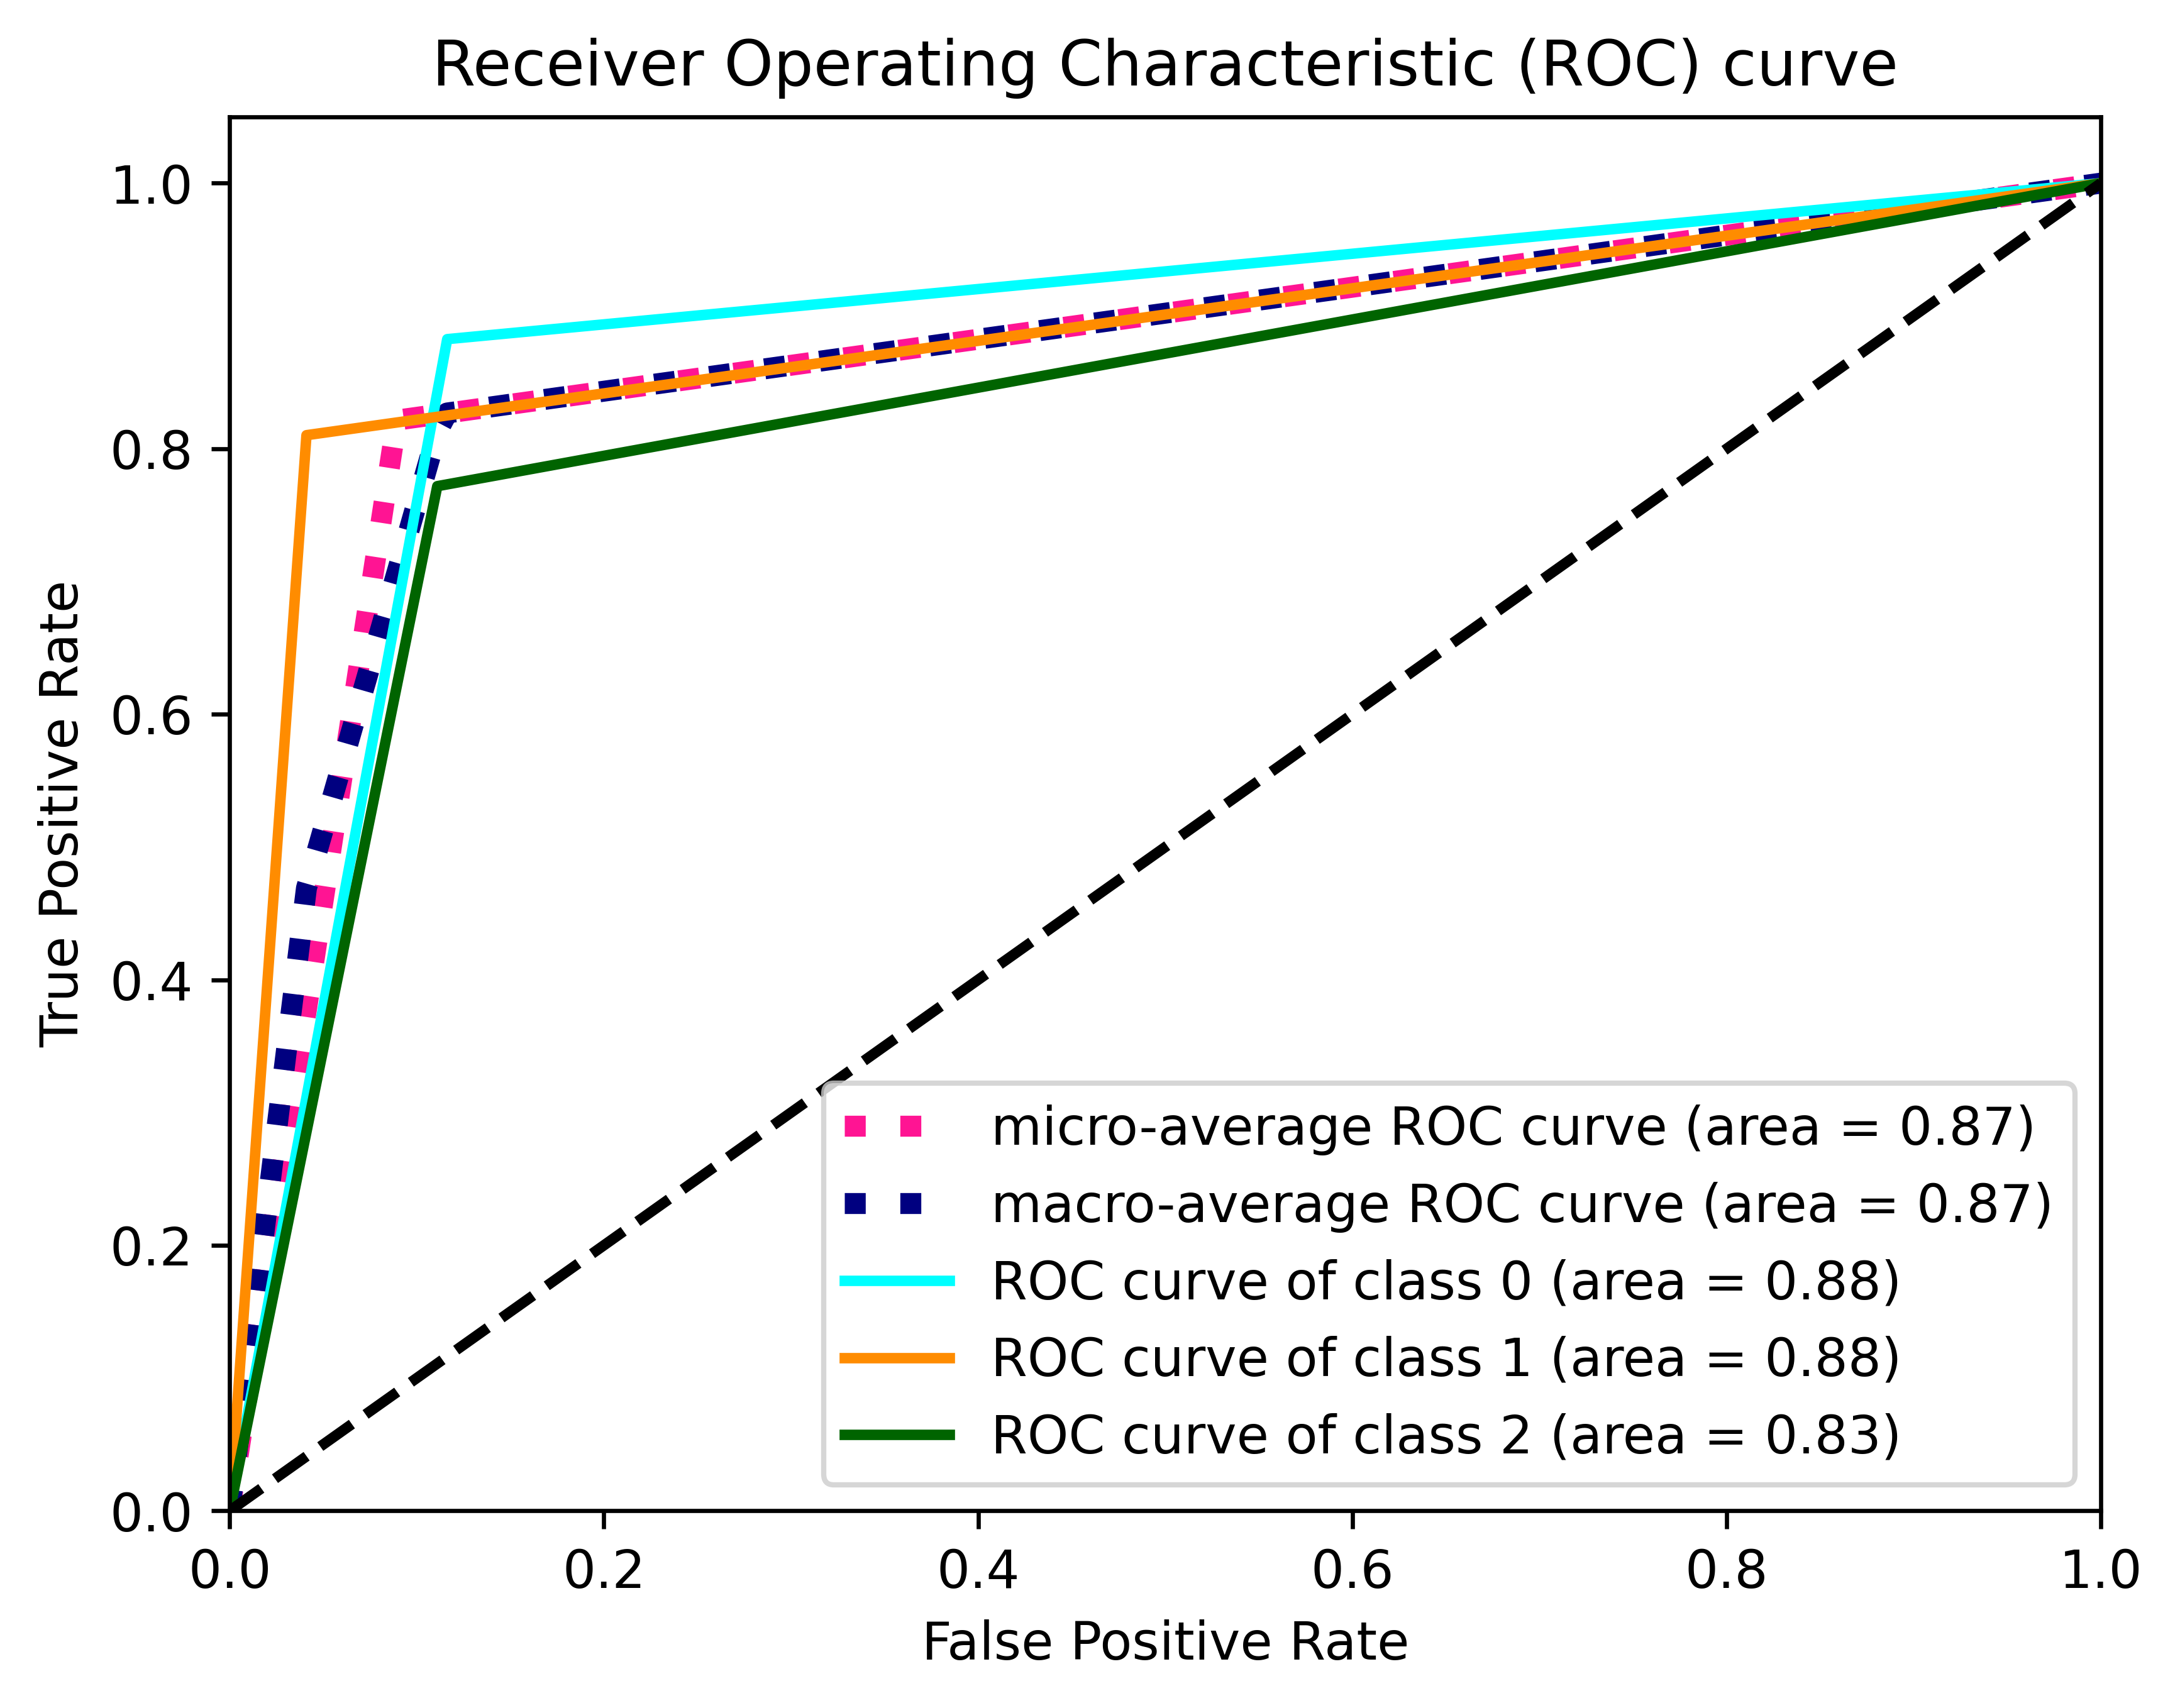

In [61]:
plot_roc_curve(labels, preds)

In [62]:
wandb.finish()

eval/accuracy,▁▃▄▄▅▅▅▅▆▆▆▇▇▇▇▇▇█████████
eval/f1_score,▁▃▄▄▅▅▅▅▆▆▆▇▇▇▇▇▇█████████
eval/loss,█▆▅▄▄▃▃▃▂▂▂▁▁▂▁▁▂▂▂▂▃▄▄▅▆▇
eval/macro_f1,▁▃▄▄▅▅▅▅▆▆▆▇▇▇▇▇▇█████████
eval/precision,▁▃▄▄▅▅▅▅▅▆▆▇▇▇▇▇▇▇████████
eval/recall,▁▃▄▄▅▅▅▅▆▆▆▇▇▇▇▇▇█████████
eval/roc_auc,▁▃▄▅▅▆▆▆▇▇▇▇▇▇████████████
eval/runtime,▁▁▁▃▂▂▂▄▂▃▅▂▂▃▆█▆▅▅▆▅▇▇▆▄▆
eval/samples_per_second,███▆▇▇▇▅▇▆▄▇▆▆▃▁▃▄▄▃▄▂▂▃▄▃
eval/steps_per_second,███▆▇▇▇▅▇▆▄▇▆▆▃▁▃▄▄▃▄▂▂▃▄▃
+16,...
